## 로지스틱 회귀


Q. 로지스틱 회귀는 왜 회귀라고 불릴까?
-> 사실 따지고 보면 시그모이드 함수의 결괏값도 결국은 0과 1 사이의 연속적인 값이기 때문에, 회귀라고 볼 수 있습니다. 그래서 '로지스틱 분류'가 아니라 '로지스틱 회귀'라고 부르는 건데요. 우리는 주로 시그모이드 함수의 결괏값이 0.5보다 큰지 작은지 보고 결국 분류를 합니다. 그러니까 이름은 로지스틱 회귀지만 사용하는 건 주로 분류라는 점.


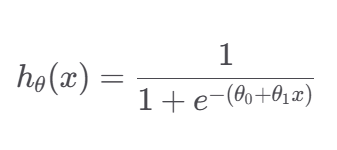

- 지수부분이 0이 되면 시그모이드 함수는 항상 0.5가 된다
- 지수 부분을 x에 대해 식을 변환하면 x=−θ1/θ0​​
- 그래서 θ0가 2, 5, 10으로 순서대로 커지면 θ1는 반대로 -2, -5, -10으로 점점 작아지므로 θ0이 커질수록 그래프는 왼쪽으로 이동한다.
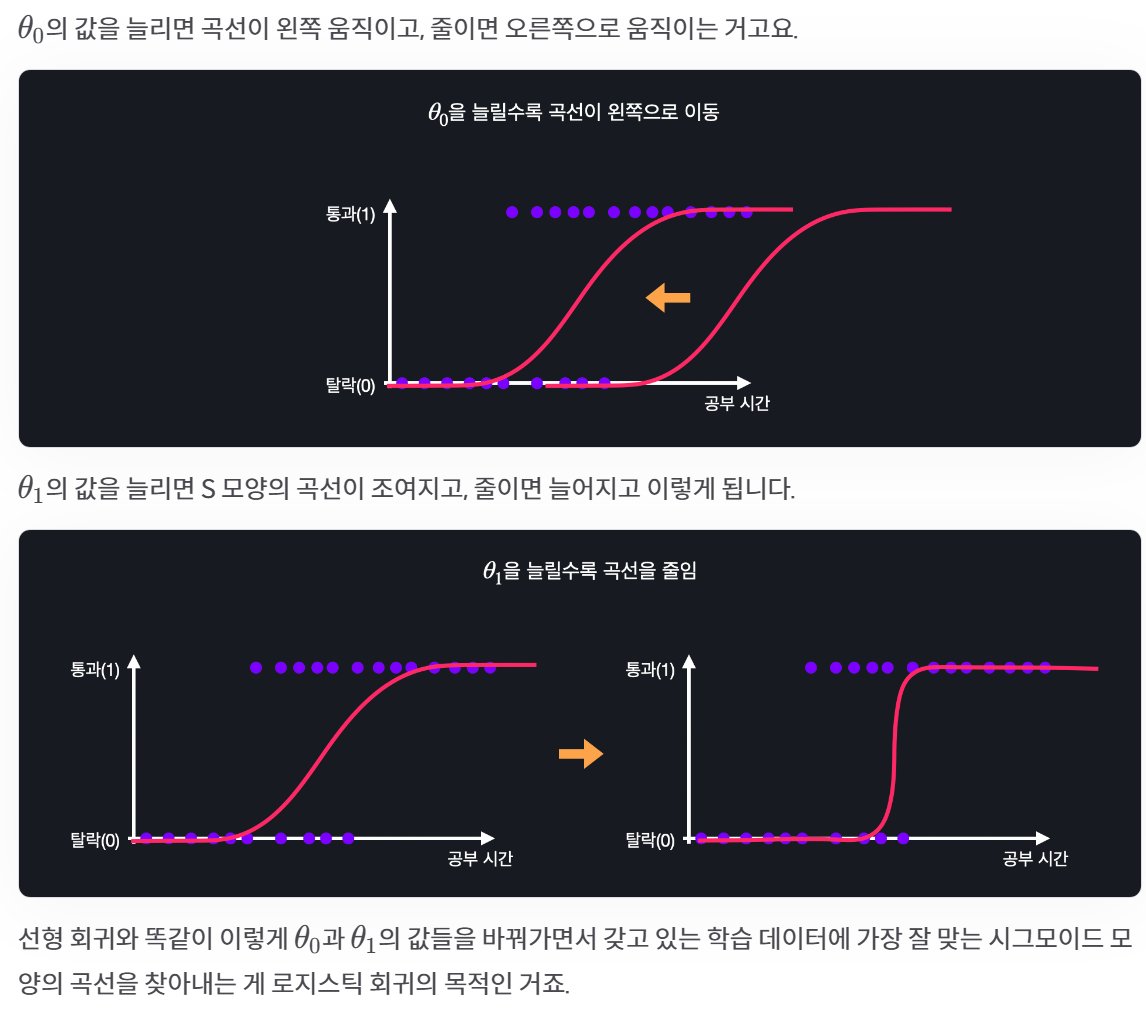

### 데이터 불러오기 

In [1]:
from sklearn.datasets import load_iris
iris_data = load_iris()

In [2]:
''' DESCR : 데이터셋 전체 설명 문자열 '''
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 입력변수, 목표변수 정의하기

In [9]:
X=pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
y = pd.DataFrame(iris_data.target, columns=['class'])
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

선형 회귀와 다르게 로지스틱 회귀에서 train/test로 스플릿 하고 y_train = y_train.values.ravel() 이런 코드를 추가해서 오류를 방지

- 코드의 목적은 y_train의 shape을 2차원에서 1차원으로 바꿈
- Logistic Regrssion은 y_train의 shape이 1차원인라는 걸 기대함
- sklearn이 1차원 (n,)을 기대하는 이유는, "샘플 하나당 라벨 하나"라는 가장 기본적인 분류 문제의 구조를 명확히 나타내는 형태이기 때문이에요. (n,1) 같은 2차원 형태는 "라벨이 여러 개일 수도 있다"는 애매함을 만들어서, sklearn이 자동으로 안전하게 처리하려고 경고를 띄우는 거예요.

In [13]:
y_train = y_train.values.ravel()

In [15]:
'''solver : 모델을 최적화할 때 어떤 알고리즘을 쓸지 결정하는 파라미터
max_iter :  최적화 시 몇 번 반복할 지 정해줌. 하지만, 모두 도는 것은 아닌 정해진 숫자 이전에 최적화가 되면 멈춤'''
model = LogisticRegression(solver='saga', max_iter=2000)

In [16]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


In [17]:
model.predict(X_test)

array([1, 2, 2, 0, 2, 1, 0, 2, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2, 0, 0, 1, 2,
       0, 1, 1, 2, 1, 1, 1, 2])

분류 문제여서 결과가 모두 0,1,2 중 하나로 나옴

In [18]:
model.score(X_test, y_test)

0.9666666666666667

해당 모델이 96% 확률로 분류함을 확인